# **Correlation Study**

## Objectives

* Expand on the cancellation EDA to answer BR1:

    *TCS Hotels wants to understand cancellation patterns, trends and guest behaviour across their 2 Portuguese properties in order to identify risk factors and develop more effective cancellation defence strategies*
* Investigate statistical relationships between features and the target variable `is_canceled` using Pearson, Spearman and PPS to indentify which features carry meaningful predictive signal
* Formally validate hypotheses 1, 2 and 3 using appropriate statistical tests
* Rank features by predictive relationship with the target to inform which engineered features are required

## Inputs

* The dataset as cleaned in the [cleaning notebook](/jupyter_notebooks/04_cleaning.ipynb):

    outputs/datasets/cleaned/HotelBookingsClean.csv

## Outputs

* Relevant correlation/PPS matrices and visualisations
* Statistical test results for H1, H2 and H3
* A ranked features table saved to outputs/correlation/RankedFeatures.csv

## Additional Comments

* p-value returned as 0.0 due to floating-point underflow at this sample size; reported as p < .001


---

# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

current_dir = os.getcwd()
current_dir

You set a new current directory


'/home/niall/PP4/cancel-protect'

## Load Data

In [70]:
import pandas as pd
df = pd.read_csv("outputs/datasets/cleaned/HotelBookingsClean.csv")
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,0,0,Transient,75.0,0,0


In [4]:
df.shape


(119192, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119192 entries, 0 to 119191
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119192 non-null  object 
 1   is_canceled                     119192 non-null  int64  
 2   lead_time                       119192 non-null  int64  
 3   arrival_date_year               119192 non-null  int64  
 4   arrival_date_month              119192 non-null  object 
 5   arrival_date_week_number        119192 non-null  int64  
 6   arrival_date_day_of_month       119192 non-null  int64  
 7   stays_in_weekend_nights         119192 non-null  int64  
 8   stays_in_week_nights            119192 non-null  int64  
 9   adults                          119192 non-null  int64  
 10  children                        119192 non-null  int64  
 11  babies                          119192 non-null  int64  
 12  meal            

* Since the category conversion of `is_repeated_guest`, `agent` and `company` was not preserved in the saving process, re-specify dtype

In [71]:
categorical_list = ["is_repeated_guest", "agent", "company"]
for col in categorical_list:
    df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119192 entries, 0 to 119191
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119192 non-null  object  
 1   is_canceled                     119192 non-null  int64   
 2   lead_time                       119192 non-null  int64   
 3   arrival_date_year               119192 non-null  int64   
 4   arrival_date_month              119192 non-null  object  
 5   arrival_date_week_number        119192 non-null  int64   
 6   arrival_date_day_of_month       119192 non-null  int64   
 7   stays_in_weekend_nights         119192 non-null  int64   
 8   stays_in_week_nights            119192 non-null  int64   
 9   adults                          119192 non-null  int64   
 10  children                        119192 non-null  int64   
 11  babies                          119192 non-null  int64   
 12  me

---

## Split Feature Groups

* The dataset contains 4 distinct feature groups:
    1. The target variable (binary) ["is_canceled"]
    2. Numeric Features
    3. Categorical Features
    4. Temporal Features

In [7]:
target = ["is_canceled"]

In [25]:
numeric_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
]

In [26]:
categorical_features = [
    "hotel",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "customer_type",
    "is_repeated_guest",
    "agent",
    "company",
]

In [10]:
temporal_features = [
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month"
]

In [27]:
numeric_correlation_df = pd.concat([df[target], df[numeric_features]], axis=1)
numeric_correlation_df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,0,342,0,0,2,0,0,0,0,3,0,0.0,0,0
1,0,737,0,0,2,0,0,0,0,4,0,0.0,0,0
2,0,7,0,1,1,0,0,0,0,0,0,75.0,0,0
3,0,13,0,1,1,0,0,0,0,0,0,75.0,0,0
4,0,14,0,2,2,0,0,0,0,0,0,98.0,0,1


---

## Pearson Correlation with Target

In [28]:
pearson_df = numeric_correlation_df.corr(method="pearson")
pearson_df

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.292638,-0.001427,0.025419,0.060927,0.004636,-0.034143,0.110171,-0.057348,-0.144810,0.054332,0.047979,-0.197122,-0.234786
lead_time,0.292638,1.000000,0.085767,0.166695,0.125971,-0.037814,-0.021565,0.086084,-0.073606,0.002291,0.170103,-0.067062,-0.117664,-0.095771
stays_in_weekend_nights,-0.001427,0.085767,1.000000,0.494108,0.108880,0.045640,0.020271,-0.012757,-0.042887,0.050157,-0.054389,0.054353,-0.019066,0.073222
stays_in_week_nights,0.025419,0.166695,0.494108,1.000000,0.111413,0.043971,0.023149,-0.013965,-0.048887,0.080018,-0.002009,0.071214,-0.025655,0.068837
adults,0.060927,0.125971,0.108880,0.111413,1.000000,0.036651,0.024979,-0.007751,-0.128842,-0.047641,-0.009109,0.293151,0.018941,0.151229
children,0.004636,-0.037814,0.045640,0.043971,0.036651,1.000000,0.026726,-0.024801,-0.021115,0.050547,-0.033357,0.342258,0.057269,0.081820
babies,-0.034143,-0.021565,0.020271,0.023149,0.024979,0.026726,1.000000,-0.008007,-0.006984,0.091195,-0.011358,0.033785,0.041751,0.106920
previous_cancellations,0.110171,0.086084,-0.012757,-0.013965,-0.007751,-0.024801,-0.008007,1.000000,0.152571,-0.027262,0.005939,-0.069216,-0.018654,-0.048501
previous_bookings_not_canceled,-0.057348,-0.073606,-0.042887,-0.048887,-0.128842,-0.021115,-0.006984,0.152571,1.000000,0.011933,-0.009417,-0.075878,0.047358,0.037774
booking_changes,-0.144810,0.002291,0.050157,0.080018,-0.047641,0.050547,0.091195,-0.027262,0.011933,1.000000,-0.011917,0.026786,0.067325,0.055009


In [29]:
import numpy as np

def heatmap_mask(df, threshold):
    mask = np.zeros_like(df, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    mask[abs(df) < threshold] = True
    return mask


* Values below ±0.1 are masked to improve readability because correlations below this level are generally considered negligible for exploratory analysis.

In [92]:
threshold = 0.1

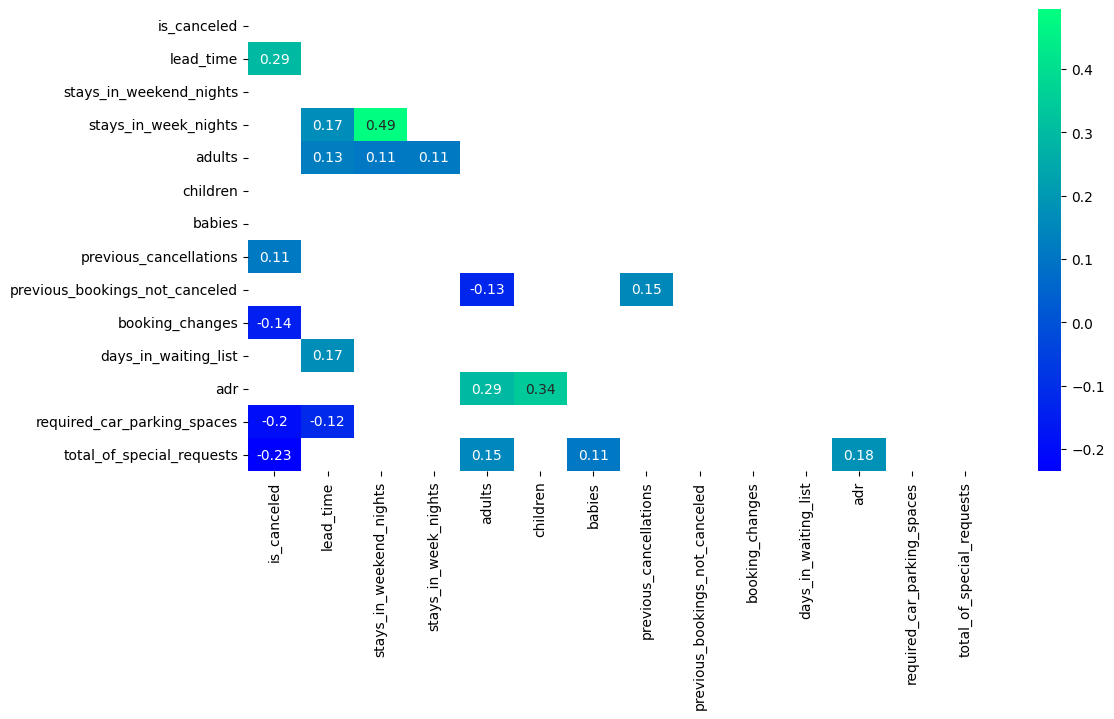

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    pearson_df, 
    mask=(heatmap_mask(pearson_df, threshold)), 
    annot=True,
    cmap="winter",
    ax=ax)

plt.show()

---

## Spearman Correlation with Target

In [33]:
spearman_df = numeric_correlation_df.corr(method="spearman")
spearman_df

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.316275,-0.004222,0.041289,0.065295,-0.003000,-0.034267,0.270394,-0.115356,-0.184301,0.098461,0.050211,-0.197513,-0.258641
lead_time,0.316275,1.000000,0.161459,0.295637,0.189624,-0.016506,-0.019793,0.170905,-0.189010,-0.006776,0.153166,0.013065,-0.141919,-0.074296
stays_in_weekend_nights,-0.004222,0.161459,1.000000,0.236450,0.126985,0.052862,0.022738,-0.055111,-0.083826,0.039302,-0.074911,0.051597,-0.018798,0.079765
stays_in_week_nights,0.041289,0.295637,0.236450,1.000000,0.152697,0.054269,0.026630,-0.062261,-0.119255,0.063483,0.011593,0.093671,-0.033997,0.076608
adults,0.065295,0.189624,0.126985,0.152697,1.000000,0.071547,0.027688,-0.036489,-0.210549,-0.081406,-0.036723,0.276740,0.017769,0.162219
children,-0.003000,-0.016506,0.052862,0.054269,0.071547,1.000000,0.039331,-0.058724,-0.035204,0.066491,-0.048129,0.265372,0.061048,0.095617
babies,-0.034267,-0.019793,0.022738,0.026630,0.027688,0.039331,1.000000,-0.017284,-0.011092,0.116242,-0.014109,0.025994,0.040706,0.092971
previous_cancellations,0.270394,0.170905,-0.055111,-0.062261,-0.036489,-0.058724,-0.017284,1.000000,0.101206,-0.072600,0.116450,-0.150559,-0.044037,-0.129709
previous_bookings_not_canceled,-0.115356,-0.189010,-0.083826,-0.119255,-0.210549,-0.035204,-0.011092,0.101206,1.000000,0.030397,-0.019120,-0.143032,0.103580,0.025078
booking_changes,-0.184301,-0.006776,0.039302,0.063483,-0.081406,0.066491,0.116242,-0.072600,0.030397,1.000000,-0.019319,0.007812,0.075646,0.042246


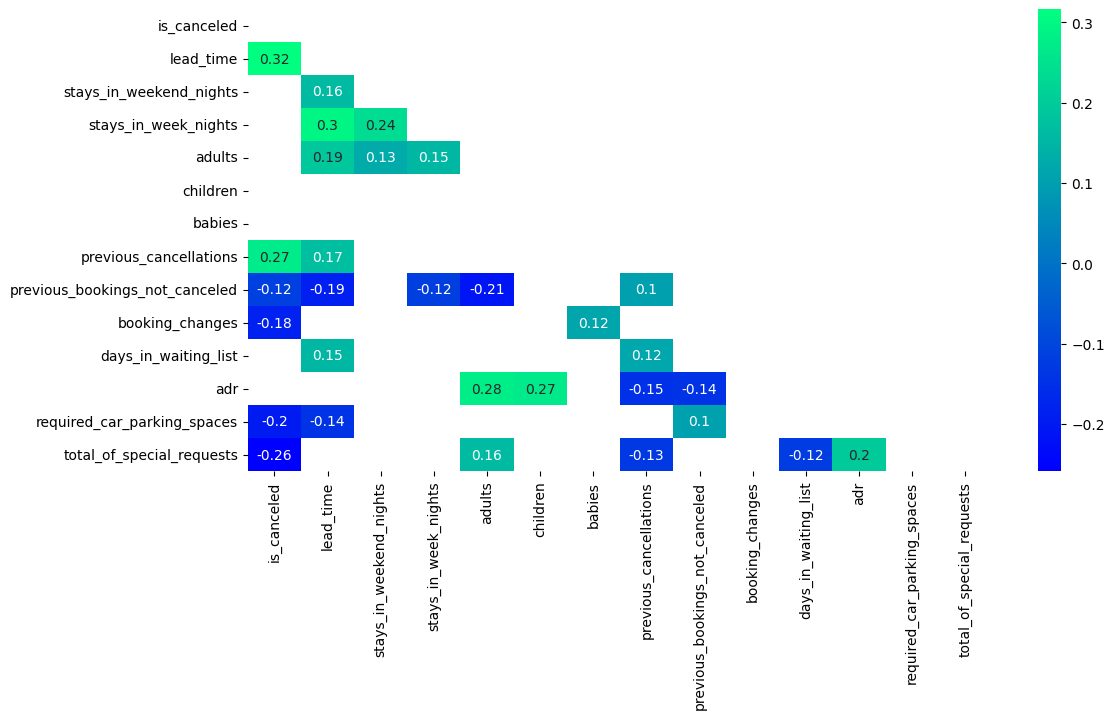

In [94]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    spearman_df, 
    mask=(heatmap_mask(spearman_df, threshold)), 
    annot=True,
    cmap="winter",
    ax=ax)

plt.show()

* Full matrices are shown to provide context for relationships between numeric predictors. Subsequent analysis focuses on the target variable.
* Compare Pearson and Spearman correlations focusing on the target variable.

In [57]:
pearson_is_canceled = pearson_df["is_canceled"].drop(labels="is_canceled")
spearman_is_canceled = spearman_df["is_canceled"].drop(labels="is_canceled")

comparison_df = pd.concat({"Spearman": spearman_is_canceled, "Pearson": pearson_is_canceled}, axis=1)
comparison_df["Difference"] = comparison_df["Spearman"] - comparison_df["Pearson"]

comparison_df





,Spearman,Pearson,Difference
lead_time,0.316275,0.292638,0.023637
stays_in_weekend_nights,-0.004222,-0.001427,-0.002795
stays_in_week_nights,0.041289,0.025419,0.015870
adults,0.065295,0.060927,0.004368
children,-0.003000,0.004636,-0.007636
babies,-0.034267,-0.034143,-0.000124
previous_cancellations,0.270394,0.110171,0.160222
previous_bookings_not_canceled,-0.115356,-0.057348,-0.058009
booking_changes,-0.184301,-0.144810,-0.039491
days_in_waiting_list,0.098461,0.054332,0.044129


* Prepare the data for plotting

In [58]:
plot_comparison = comparison_df.reset_index(names="Feature")
plot_comparison = plot_comparison.drop(columns="Difference")
plot_comparison

,Feature,Spearman,Pearson
0,lead_time,0.316275,0.292638
1,stays_in_weekend_nights,-0.004222,-0.001427
2,stays_in_week_nights,0.041289,0.025419
3,adults,0.065295,0.060927
4,children,-0.003000,0.004636
5,babies,-0.034267,-0.034143
6,previous_cancellations,0.270394,0.110171
7,previous_bookings_not_canceled,-0.115356,-0.057348
8,booking_changes,-0.184301,-0.144810
9,days_in_waiting_list,0.098461,0.054332


In [59]:
plot_comparison = plot_comparison.melt(id_vars="Feature", value_vars=["Pearson", "Spearman"], var_name="Method", value_name="Value")
plot_comparison

,Feature,Method,Value
0,lead_time,Pearson,0.292638
1,stays_in_weekend_nights,Pearson,-0.001427
2,stays_in_week_nights,Pearson,0.025419
3,adults,Pearson,0.060927
4,children,Pearson,0.004636
5,babies,Pearson,-0.034143
6,previous_cancellations,Pearson,0.110171
7,previous_bookings_not_canceled,Pearson,-0.057348
8,booking_changes,Pearson,-0.144810
9,days_in_waiting_list,Pearson,0.054332


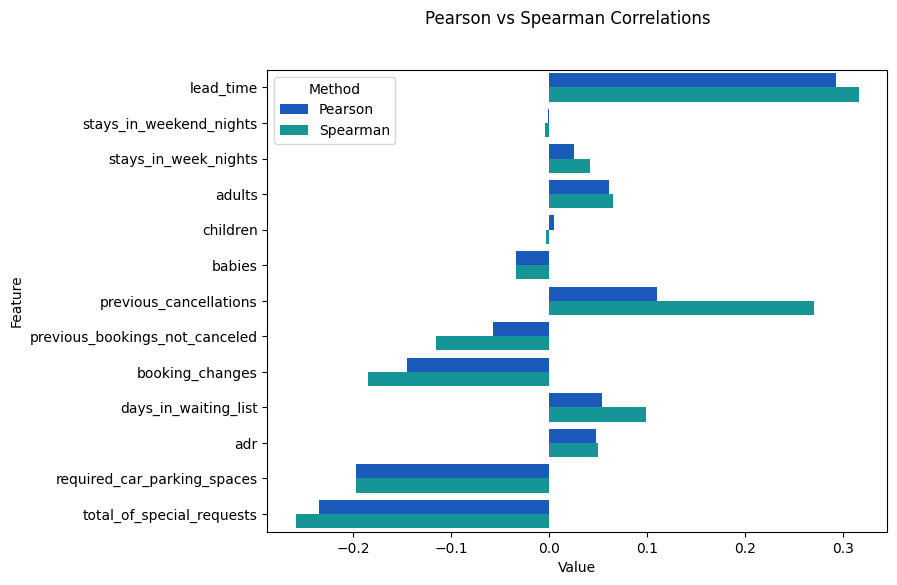

In [82]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Pearson vs Spearman Correlations")

sns.barplot(data=plot_comparison,
            x="Value",
            y="Feature",
            hue="Method",
            palette="winter")

plt.show()

* From the chart we can see that the two methods broadly agree though they diverge most on `previous_cancellations`, `previous_bookings_not_canceled` and `days_in_waiting_list`, where Spearman scores are notably larger. This is consistent with their shared heavily-skewed, zero-inflated distributions. 

---

## Predictive Power Score

In [72]:
import ppscore as pps

pps_df = df.copy()

pps_df["is_canceled"] = pps_df["is_canceled"].astype("category")

pps_predict = pps.predictors(pps_df, y="is_canceled")
pps_predict.sort_values(by="ppscore", ascending=False)


,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,deposit_type,is_canceled,0.395261,classification,True,weighted F1,0.5276,0.714321,DecisionTreeClassifier()
1,country,is_canceled,0.342625,classification,True,weighted F1,0.5276,0.689456,DecisionTreeClassifier()
2,agent,is_canceled,0.255838,classification,True,weighted F1,0.5276,0.648458,DecisionTreeClassifier()
3,adr,is_canceled,0.238616,classification,True,weighted F1,0.5276,0.640322,DecisionTreeClassifier()
4,lead_time,is_canceled,0.219539,classification,True,weighted F1,0.5276,0.631310,DecisionTreeClassifier()
5,market_segment,is_canceled,0.217399,classification,True,weighted F1,0.5276,0.630299,DecisionTreeClassifier()
6,previous_cancellations,is_canceled,0.138404,classification,True,weighted F1,0.5276,0.592982,DecisionTreeClassifier()
7,hotel,is_canceled,0.000000,classification,True,weighted F1,0.5276,0.494243,DecisionTreeClassifier()
8,arrival_date_year,is_canceled,0.000000,classification,True,weighted F1,0.5276,0.494243,DecisionTreeClassifier()
9,arrival_date_month,is_canceled,0.000000,classification,True,weighted F1,0.5276,0.494243,DecisionTreeClassifier()


In [73]:
pps_plot_df = pps_predict[pps_predict["ppscore"] > 0].sort_values(by="ppscore", ascending=False) 
pps_plot_df


,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,deposit_type,is_canceled,0.395261,classification,True,weighted F1,0.5276,0.714321,DecisionTreeClassifier()
1,country,is_canceled,0.342625,classification,True,weighted F1,0.5276,0.689456,DecisionTreeClassifier()
2,agent,is_canceled,0.255838,classification,True,weighted F1,0.5276,0.648458,DecisionTreeClassifier()
3,adr,is_canceled,0.238616,classification,True,weighted F1,0.5276,0.640322,DecisionTreeClassifier()
4,lead_time,is_canceled,0.219539,classification,True,weighted F1,0.5276,0.631310,DecisionTreeClassifier()
5,market_segment,is_canceled,0.217399,classification,True,weighted F1,0.5276,0.630299,DecisionTreeClassifier()
6,previous_cancellations,is_canceled,0.138404,classification,True,weighted F1,0.5276,0.592982,DecisionTreeClassifier()


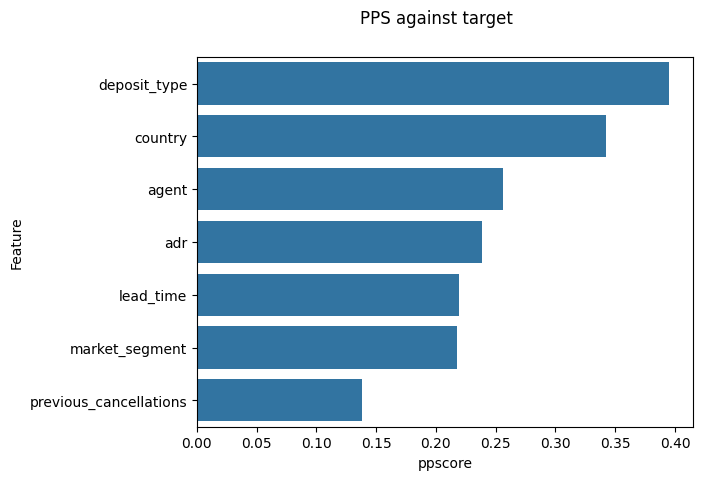

In [81]:
fig, ax = plt.subplots()
fig.suptitle("PPS against target")
ax.set_ylabel("Feature")

sns.barplot(data=pps_plot_df,
            x="ppscore",
            y="x")

plt.show()

---

## Feature Ranking

* From the 3 correlation methods performed, we can now derive a set of relevant features
* The threshold of 0.1 has been kept for Pearson and Spearman correlations as a preferred cut-off rather than simply taking the top n features from each.

In [97]:
pearson = pd.Series(pearson_df["is_canceled"]).drop(labels="is_canceled")
pearson = pearson.reindex(pearson.abs().sort_values(ascending=False).index)
pearson = pearson[pearson.abs() > threshold]
pearson

lead_time                      0.292638
total_of_special_requests     -0.234786
required_car_parking_spaces   -0.197122
booking_changes               -0.144810
previous_cancellations         0.110171
Name: is_canceled, dtype: float64

In [98]:
spearman = pd.Series(spearman_df["is_canceled"]).drop(labels="is_canceled")
spearman = spearman.reindex(spearman.abs().sort_values(ascending=False).index)
spearman = spearman[spearman.abs() > threshold]
spearman

lead_time                         0.316275
previous_cancellations            0.270394
total_of_special_requests        -0.258641
required_car_parking_spaces      -0.197513
booking_changes                  -0.184301
previous_bookings_not_canceled   -0.115356
Name: is_canceled, dtype: float64

In [105]:
pps_col = pps_plot_df.set_index("x")["ppscore"].sort_values(ascending=False)
pps_col

x
deposit_type              0.395261
country                   0.342625
agent                     0.255838
adr                       0.238616
lead_time                 0.219539
market_segment            0.217399
previous_cancellations    0.138404
Name: ppscore, dtype: float64

In [ ]:
all_features = pearson.index.union(spearman.index).union(pps_col.index)

ranked_df = pd.DataFrame(index=all_features)
ranked_df["pps"] = pps_col
ranked_df["pearson"] = pearson
ranked_df["spearman"] = spearman

# Scores are ordered primarily by pps as the only method able to assess all variables 
ranked_df.sort_values(by="pps", ascending=False)

,pps,pearson,spearman
deposit_type,0.395261,NaN,NaN
country,0.342625,NaN,NaN
agent,0.255838,NaN,NaN
adr,0.238616,NaN,NaN
lead_time,0.219539,0.292638,0.316275
market_segment,0.217399,NaN,NaN
previous_cancellations,0.138404,0.110171,0.270394
booking_changes,NaN,-0.144810,-0.184301
previous_bookings_not_canceled,NaN,NaN,-0.115356
required_car_parking_spaces,NaN,-0.197122,-0.197513


* Expand the ranked features dataframe to include type information

In [ ]:
ranked_df = ranked_df.reset_index(names="feature")

ranked_df

,feature,pps,pearson,spearman
0,adr,0.238616,NaN,NaN
1,agent,0.255838,NaN,NaN
2,booking_changes,NaN,-0.144810,-0.184301
3,country,0.342625,NaN,NaN
4,deposit_type,0.395261,NaN,NaN
5,lead_time,0.219539,0.292638,0.316275
6,market_segment,0.217399,NaN,NaN
7,previous_bookings_not_canceled,NaN,NaN,-0.115356
8,previous_cancellations,0.138404,0.110171,0.270394
9,required_car_parking_spaces,NaN,-0.197122,-0.197513


In [113]:
feature_type = []

for feature in ranked_df["feature"]:
    if feature in numeric_features:
        feature_type.append("numeric")
    elif feature in categorical_features:
        feature_type.append("categorical")

ranked_df["feature_type"] = feature_type
ranked_df

,feature,pps,pearson,spearman,feature_type
0,adr,0.238616,NaN,NaN,numeric
1,agent,0.255838,NaN,NaN,categorical
2,booking_changes,NaN,-0.144810,-0.184301,numeric
3,country,0.342625,NaN,NaN,categorical
4,deposit_type,0.395261,NaN,NaN,categorical
5,lead_time,0.219539,0.292638,0.316275,numeric
6,market_segment,0.217399,NaN,NaN,categorical
7,previous_bookings_not_canceled,NaN,NaN,-0.115356,numeric
8,previous_cancellations,0.138404,0.110171,0.270394,numeric
9,required_car_parking_spaces,NaN,-0.197122,-0.197513,numeric


* Assess agreememnt between methods 

In [116]:
ranked_df["n_methods"] = ranked_df.count(axis=1, numeric_only=True)
ranked_df

,feature,pps,pearson,spearman,feature_type,n_methods
0,adr,0.238616,NaN,NaN,numeric,1
1,agent,0.255838,NaN,NaN,categorical,1
2,booking_changes,NaN,-0.144810,-0.184301,numeric,2
3,country,0.342625,NaN,NaN,categorical,1
4,deposit_type,0.395261,NaN,NaN,categorical,1
5,lead_time,0.219539,0.292638,0.316275,numeric,3
6,market_segment,0.217399,NaN,NaN,categorical,1
7,previous_bookings_not_canceled,NaN,NaN,-0.115356,numeric,1
8,previous_cancellations,0.138404,0.110171,0.270394,numeric,3
9,required_car_parking_spaces,NaN,-0.197122,-0.197513,numeric,2


* Rank variables within feature type

In [124]:
ranked_df["strongest_signal"] = ranked_df[["pps", "pearson", "spearman"]].abs().max(axis=1)

ranked_df["rank_in_type"] = (
    ranked_df.sort_values(by=["n_methods", "strongest_signal"], ascending=False)
    .groupby("feature_type")
    .cumcount() + 1
)

ranked_df.sort_values(by=["feature_type", "rank_in_type"])

,feature,pps,pearson,spearman,feature_type,n_methods,rank_in_type,strongest_signal
4,deposit_type,0.395261,NaN,NaN,categorical,1,1,0.395261
3,country,0.342625,NaN,NaN,categorical,1,2,0.342625
1,agent,0.255838,NaN,NaN,categorical,1,3,0.255838
6,market_segment,0.217399,NaN,NaN,categorical,1,4,0.217399
5,lead_time,0.219539,0.292638,0.316275,numeric,3,1,0.316275
8,previous_cancellations,0.138404,0.110171,0.270394,numeric,3,2,0.270394
10,total_of_special_requests,NaN,-0.234786,-0.258641,numeric,2,3,0.258641
9,required_car_parking_spaces,NaN,-0.197122,-0.197513,numeric,2,4,0.197513
2,booking_changes,NaN,-0.144810,-0.184301,numeric,2,5,0.184301
0,adr,0.238616,NaN,NaN,numeric,1,6,0.238616


* Variables are now ranked within their category type, prioritised based on the number of methods that flagged the feature, then the strength of the strongest signal

---

## Hypothesis Testing

### H1: No deposit bookings cancel more than deposit-secured bookings

* Validation method is chi-squared test on `deposit_type` vs `is_canceled`

In [134]:
h1_df = pd.crosstab(df["deposit_type"], df["is_canceled"])
h1_df

is_canceled,0,1
deposit_type,,
No Deposit,74791,29653
Non Refund,93,14493
Refundable,126,36


In [126]:
import pingouin as pg

expected, observed, stats = pg.chi2_independence(data=df, x="deposit_type", y="is_canceled")
stats


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,27650.115750,2.0,0.0,0.481643,1.0
1,cressie-read,0.666667,27521.088117,2.0,0.0,0.480518,1.0
2,log-likelihood,0.000000,31248.242643,2.0,0.0,0.512023,1.0
3,freeman-tukey,-0.500000,42080.086447,2.0,0.0,0.594176,1.0
4,mod-log-likelihood,-1.000000,77329.498441,2.0,0.0,0.805469,1.0
5,neyman,-2.000000,897330.462737,2.0,0.0,2.743801,1.0


* The Cramer's V effect values shows that there is a statistical relationship between the 2 variables.

In [136]:
h1_df = pd.crosstab(df["deposit_type"], df["is_canceled"], normalize="index")
h1_df.columns = ["not_canceled", "canceled"]

h1_df.style.format({"not_canceled": "{:.0%}", "canceled": "{:.0%}"})

,not_canceled,canceled
deposit_type,,
No Deposit,72%,28%
Non Refund,1%,99%
Refundable,78%,22%


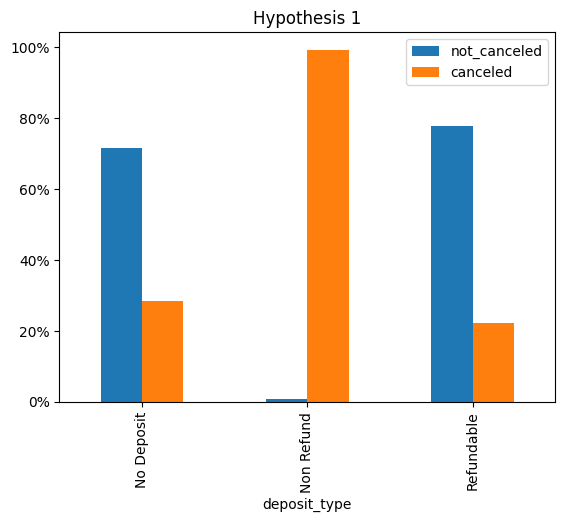

In [137]:
import matplotlib.ticker as mticker

h1_df.plot(kind="bar").yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.title("Hypothesis 1")
plt.show()

* However, as the chart demonstrates, the relationship is counter to the expected direction with the majority of non-refund (or pre-paid) bookings cancelling.

**Conclusion**

The crosstab shows the opposite pattern to that proposed in H1: Non Refund bookings - a deposit-secured type - show a substantially higher cancellation rate than No Deposit bookings.

The chi-square test confirms this relationship is statistically significant (chi2 = 27650.12, p < 0.001) with a moderate effect size (Cramer's V = 0.48).

H1 as stated is therefore **rejected** - deposit-secured bookings, specifically the Non Refund type, cancel more than no-deposit bookings.

As a cancellation predictor, the feature remains a risk factor, just not in the way hypothesised.

This may suggest a product misalignment, an overly broad deposit-type categorisation or property specific customer behaviour that the revenue management team can explore further should they wish.

### H2: Bookings with longer lead times have a higher cancellation rate than last-minute bookings

* Validation method is point-biserial correlation between `lead_time` and `is_canceled`

In [143]:
from scipy import stats

correlation, pvalue = stats.pointbiserialr(df["is_canceled"], df["lead_time"])

h2_stats = pd.DataFrame({
    "correlation": correlation,
    "pvalue": pvalue
}, index=["lead_time_vs_is_canceled"])

h2_stats.style.format("{:.4f}")

,correlation,pvalue
lead_time_vs_is_canceled,0.2926,0.0000


NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In case you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)
